# FMCG Sales Performance Analysis
## Notebook 02 Exploratory Data Analysis (EDA)

**Author:** Ardi Gunawan Pratama  
**Input:** `cleaned_FMCG_data.csv`  
**Coverage:** Jan 2022 – Dec 2024 | 190,757 rows | 26 columns

---

### Notebook Structure

| Section | Analysis | Business Question |
|---|---|---|
| 1 | Setup & Load | — |
| 2 | Distribution Overview | What is the distribution of key numerical variables? |
| 3 | Category Analysis | Which product categories are most profitable? |
| 4 | Channel Analysis | Which distribution channel is the most effective? |
| 5 | Regional Analysis | Which region is underperforming? |
| 6 | Promotion Effect | How significant is the impact of promotions on sales? |
| 7 | Time Trend Analysis | What are the YoY revenue trends and seasonal patterns? |
| 8 | Brand Analysis | Which brands dominate in each category? |
| 9 | Sell-Through & Operations | How efficient is the product distribution? |
| 10 | Correlation & Heatmap | Which variables have the most influence? |
| 11 | Key Findings Summary | — |

# Setup


In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os

In [2]:
# Global plot style
PALETTE  = ["#4C9BE8","#52B788","#F4A261","#E76F51","#9B5DE5",
            "#F72585","#4CC9F0","#06D6A0","#FFD166","#EF476F"]
CAT_PAL  = {"Milk":"#4C9BE8","Yogurt":"#52B788","ReadyMeal":"#F4A261",
            "SnackBar":"#9B5DE5","Juice":"#E76F51"}
CH_PAL   = {"Retail":"#4CC9F0","Discount":"#F72585","E-commerce":"#06D6A0"}
REG_PAL  = {"PL-North":"#4C9BE8","PL-South":"#52B788","PL-Central":"#F4A261"}

plt.rcParams.update({
    "figure.facecolor" : "white",
    "axes.facecolor"   : "#f9f9f9",
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "font.family"      : "sans-serif",
    "axes.titlesize"   : 12,
    "axes.titleweight" : "bold",
    "axes.labelsize"   : 10,
})

In [3]:
def fmt_m(x, _): return f"{x/1e6:.1f}M"   # revenue axis formatter
def fmt_k(x, _): return f"{x/1e3:.0f}K"   # units axis formatter

In [4]:
from google.colab import files

uploaded = files.upload()

for filename in uploaded.keys():
  print(f'Uploaded file "{filename}"')
  df = pd.read_csv(filename)
  print(f'Successfully loaded "{filename}" into a pandas DataFrame.')

df.head()

Saving cleaned_FMCG_data.csv to cleaned_FMCG_data.csv
Uploaded file "cleaned_FMCG_data.csv"
Successfully loaded "cleaned_FMCG_data.csv" into a pandas DataFrame.


,date,sku,brand,segment,category,channel,region,pack_type,price_unit,promotion_flag,...,stock_adequate,is_promoted,year,month,month_name,quarter,yearmonth,day_of_week,is_weekend,delivery_tier
0,2022-01-21,MI-006,MiBrand1,Milk-Seg3,Milk,Retail,PL-Central,Multipack,2.38,0,...,1,Non-Promoted,2022,1,Jan,Q1,2022-01,4,0,Same Day
1,2022-01-21,MI-006,MiBrand1,Milk-Seg3,Milk,Retail,PL-North,Single,1.55,1,...,0,Promoted,2022,1,Jan,Q1,2022-01,4,0,Standard (3d)
2,2022-01-21,MI-006,MiBrand1,Milk-Seg3,Milk,Retail,PL-South,Carton,4.00,0,...,0,Non-Promoted,2022,1,Jan,Q1,2022-01,4,0,Slow (4-5d)
3,2022-01-21,MI-006,MiBrand1,Milk-Seg3,Milk,Discount,PL-Central,Single,5.16,0,...,0,Non-Promoted,2022,1,Jan,Q1,2022-01,4,0,Fast (2d)
4,2022-01-21,MI-006,MiBrand1,Milk-Seg3,Milk,Discount,PL-North,Single,7.66,0,...,0,Non-Promoted,2022,1,Jan,Q1,2022-01,4,0,Slow (4-5d)


In [5]:
# Restore categorical dtypes after CSV round-trip
df["delivery_tier"] = pd.Categorical(
    df["delivery_tier"],
    categories=["Same Day","Fast (2d)","Standard (3d)","Slow (4-5d)"],
    ordered=True
)

In [6]:
df['date'] = pd.to_datetime(df['date'])
print(f"Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"  Date range : {df['date'].min().date()} to {df['date'].max().date()}")
print(f"  Categories : {df['category'].unique().tolist()}")
print(f"  Channels   : {df['channel'].unique().tolist()}")
print(f"  Regions    : {df['region'].unique().tolist()}")

Dataset loaded: 190,757 rows × 26 columns
  Date range : 2022-01-21 to 2024-12-31
  Categories : ['Milk', 'Yogurt', 'ReadyMeal', 'Juice', 'SnackBar']
  Channels   : ['Retail', 'Discount', 'E-commerce']
  Regions    : ['PL-Central', 'PL-North', 'PL-South']


# Distribution Overview
**Business Question:** What is the distribution of key numerical variables? Are there any skewness or anomalies?

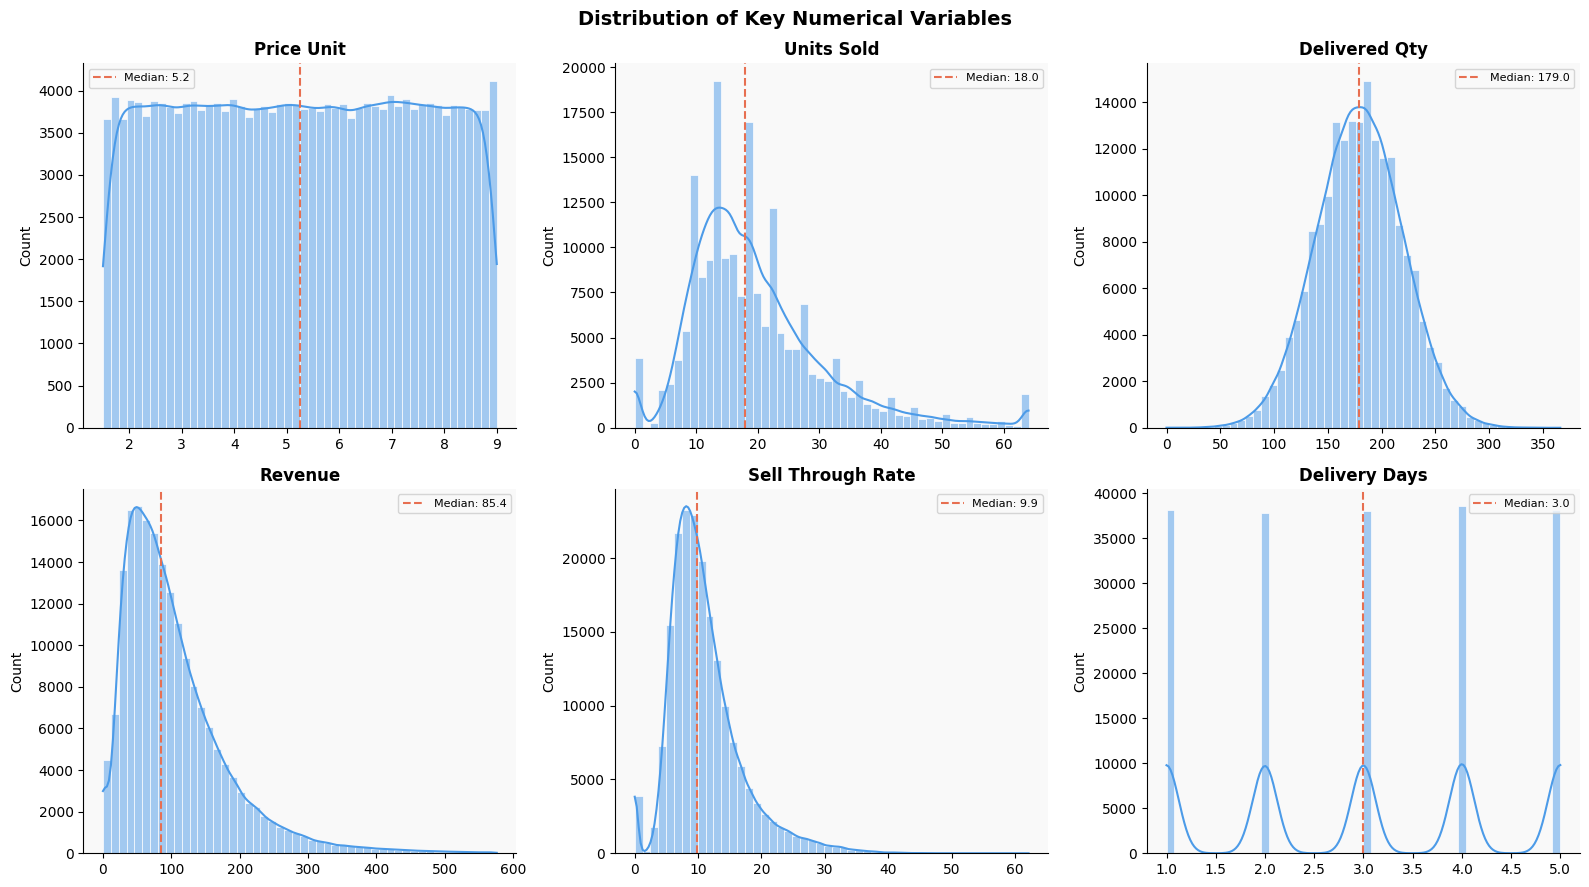

In [7]:
num_cols = ["price_unit","units_sold","delivered_qty","revenue","sell_through_rate","delivery_days"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Distribution of Key Numerical Variables", fontsize=14, fontweight="bold")

for ax, col in zip(axes.flat, num_cols):
    sns.histplot(df[col], bins=50, ax=ax, color="#4C9BE8", edgecolor="white", kde=True)
    ax.set_title(col.replace("_"," ").title())
    ax.set_xlabel("")
    median = df[col].median()
    ax.axvline(median, color="#E76F51", linestyle="--", linewidth=1.5, label=f"Median: {median:.1f}")
    ax.legend(fontsize=8)

plt.tight_layout()

In [8]:
print("Summary Statistics:")
df[num_cols].describe().round(2)

Summary Statistics:


,price_unit,units_sold,delivered_qty,revenue,sell_through_rate,delivery_days
count,190757.00,190757.00,190757.00,190757.00,190757.00,190757.00
mean,5.25,19.81,179.33,104.03,11.04,3.00
std,2.17,11.24,40.04,76.99,5.69,1.41
min,1.50,0.00,0.00,0.00,0.00,1.00
25%,3.38,12.00,152.00,50.50,7.32,2.00
50%,5.25,18.00,179.00,85.44,9.89,3.00
75%,7.13,25.00,206.00,136.00,13.42,4.00
max,9.00,64.00,366.00,576.00,62.14,5.00


# Product Category Analysis
**Business Question:** Which product category generates the highest revenue? Which is the most efficient in terms of sales?

In [9]:
cat_agg = (
    df.groupby("category")
    .agg(
        total_revenue    = ("revenue",          "sum"),
        total_units      = ("units_sold",       "sum"),
        avg_price        = ("price_unit",        "mean"),
        avg_sell_through = ("sell_through_rate", "mean"),
        n_transactions   = ("revenue",           "count"),
    )
    .round(2)
    .sort_values("total_revenue", ascending=False)
)
cat_agg["revenue_share_%"] = (cat_agg["total_revenue"] / cat_agg["total_revenue"].sum() * 100).round(1)
cat_agg

,total_revenue,total_units,avg_price,avg_sell_through,n_transactions,revenue_share_%
category,,,,,,
Yogurt,8157378.03,1552888,5.26,11.90,72707,41.1
Milk,4087137.67,781159,5.23,9.77,44595,20.6
ReadyMeal,3566492.29,676951,5.27,11.01,34236,18.0
SnackBar,3383835.83,644158,5.25,11.12,32276,17.1
Juice,649785.40,123887,5.27,9.93,6943,3.3


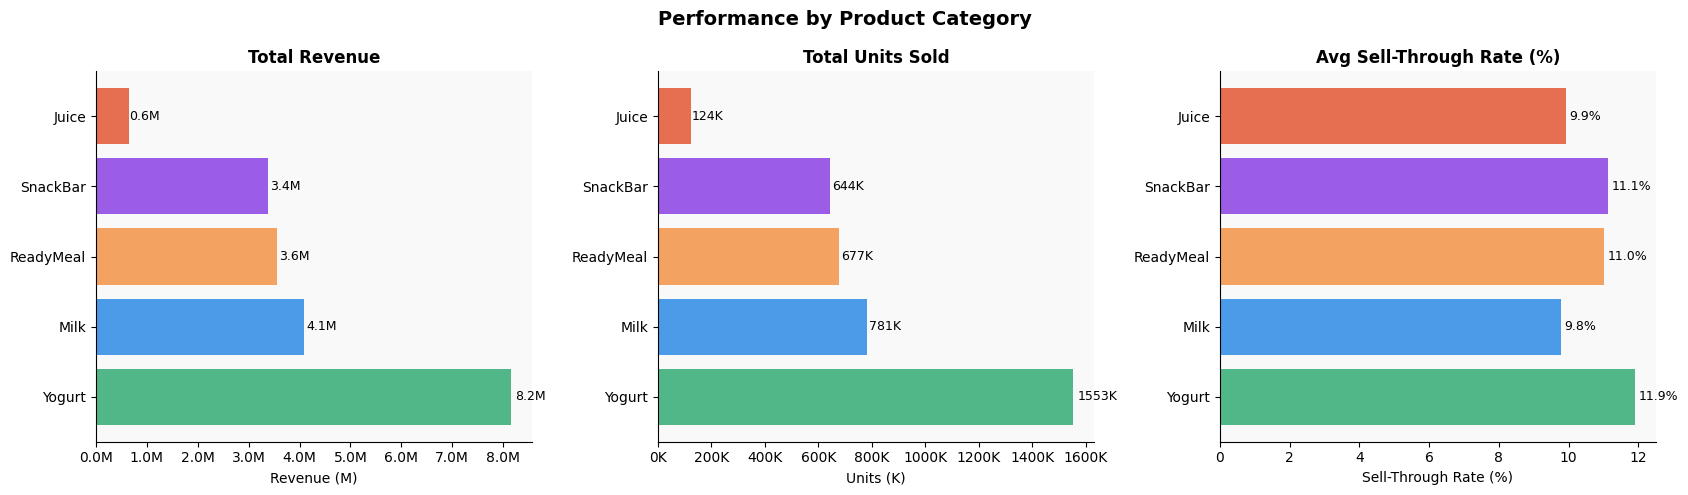

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("Performance by Product Category", fontsize=14, fontweight="bold")
colors = [CAT_PAL.get(c,"#aaa") for c in cat_agg.index]

# Revenue
ax = axes[0]
bars = ax.barh(cat_agg.index, cat_agg["total_revenue"], color=colors)
ax.set_title("Total Revenue")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_m))
ax.set_xlabel("Revenue (M)")
for bar, val in zip(bars, cat_agg["total_revenue"]):
    ax.text(bar.get_width()*1.01, bar.get_y()+bar.get_height()/2,
            f"{val/1e6:.1f}M", va="center", fontsize=9)

# Units Sold
ax = axes[1]
bars = ax.barh(cat_agg.index, cat_agg["total_units"], color=colors)
ax.set_title("Total Units Sold")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
ax.set_xlabel("Units (K)")
for bar, val in zip(bars, cat_agg["total_units"]):
    ax.text(bar.get_width()*1.01, bar.get_y()+bar.get_height()/2,
            f"{val/1e3:.0f}K", va="center", fontsize=9)

# Avg Sell-Through Rate
ax = axes[2]
bars = ax.barh(cat_agg.index, cat_agg["avg_sell_through"], color=colors)
ax.set_title("Avg Sell-Through Rate (%)")
ax.set_xlabel("Sell-Through Rate (%)")
for bar, val in zip(bars, cat_agg["avg_sell_through"]):
    ax.text(bar.get_width()+0.1, bar.get_y()+bar.get_height()/2,
            f"{val:.1f}%", va="center", fontsize=9)

plt.tight_layout()

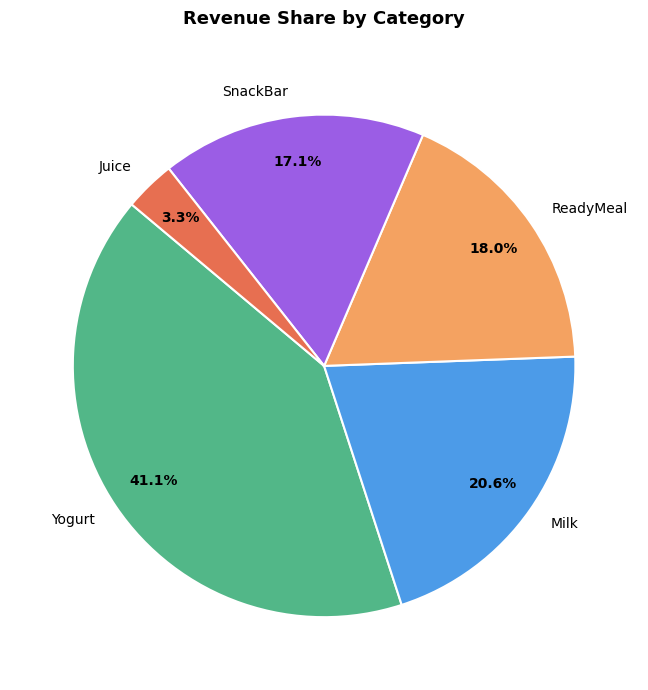

In [11]:
# Revenue share pie chart
fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(
    cat_agg["total_revenue"],
    labels=cat_agg.index,
    autopct="%1.1f%%",
    colors=[CAT_PAL.get(c,"#aaa") for c in cat_agg.index],
    startangle=140,
    pctdistance=0.82,
    wedgeprops={"linewidth":1.5,"edgecolor":"white"}
)
for t in autotexts: t.set_fontsize(10); t.set_fontweight("bold")
ax.set_title("Revenue Share by Category", fontsize=13, fontweight="bold", pad=20)
plt.tight_layout()

# Distribution Channel Analysis
**Business Question:** Which channel is the most effective in terms of revenue and volume? Has E-commerce surpassed Retail?

In [12]:
ch_agg = (
    df.groupby("channel")
    .agg(
        total_revenue    = ("revenue",          "sum"),
        total_units      = ("units_sold",       "sum"),
        avg_sell_through = ("sell_through_rate", "mean"),
        avg_price        = ("price_unit",        "mean"),
    )
    .round(2)
    .sort_values("total_revenue", ascending=False)
)
ch_agg["revenue_share_%"] = (ch_agg["total_revenue"] / ch_agg["total_revenue"].sum() * 100).round(1)
ch_agg

,total_revenue,total_units,avg_sell_through,avg_price,revenue_share_%
channel,,,,,
Retail,6623765.11,1260894,11.01,5.26,33.4
E-commerce,6614752.26,1261342,11.06,5.24,33.3
Discount,6606111.85,1256807,11.04,5.26,33.3


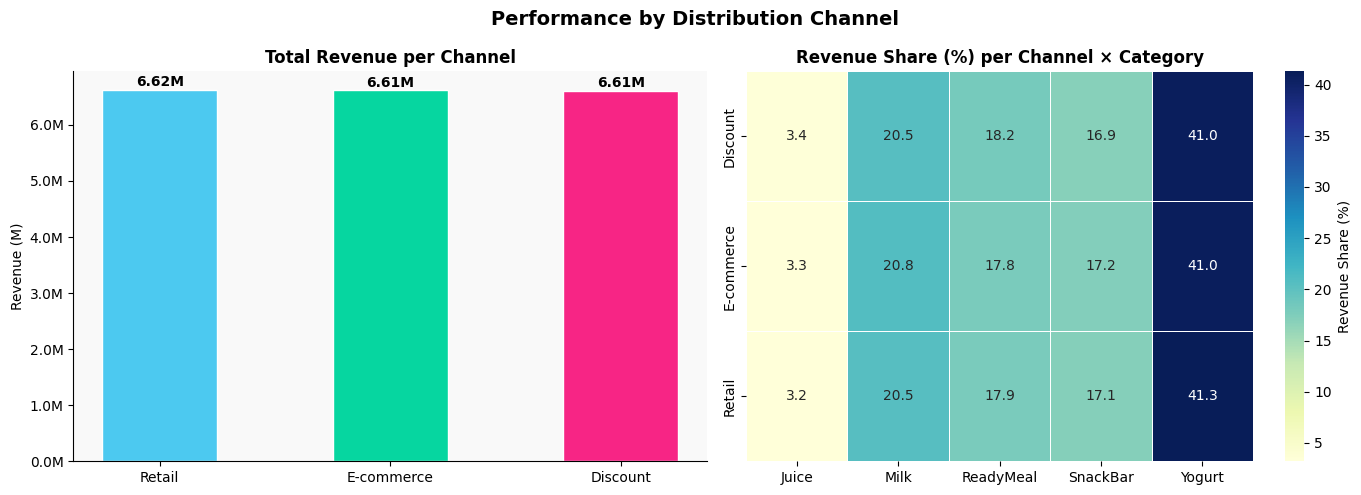

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Performance by Distribution Channel", fontsize=14, fontweight="bold")
colors = [CH_PAL.get(c,"#aaa") for c in ch_agg.index]

ax = axes[0]
bars = ax.bar(ch_agg.index, ch_agg["total_revenue"], color=colors, width=0.5, edgecolor="white")
ax.set_title("Total Revenue per Channel")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_m))
ax.set_ylabel("Revenue (M)")
for bar, val in zip(bars, ch_agg["total_revenue"]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.01,
            f"{val/1e6:.2f}M", ha="center", fontsize=10, fontweight="bold")

ax = axes[1]
# Channel x Category heatmap revenue
pivot_ch_cat = df.pivot_table(values="revenue", index="channel", columns="category", aggfunc="sum")
pivot_ch_cat_pct = pivot_ch_cat.div(pivot_ch_cat.sum(axis=1), axis=0) * 100
sns.heatmap(pivot_ch_cat_pct.round(1), annot=True, fmt=".1f", cmap="YlGnBu",
            ax=ax, linewidths=0.5, cbar_kws={"label":"Revenue Share (%)"})
ax.set_title("Revenue Share (%) per Channel × Category")
ax.set_xlabel("")
ax.set_ylabel("")

plt.tight_layout()

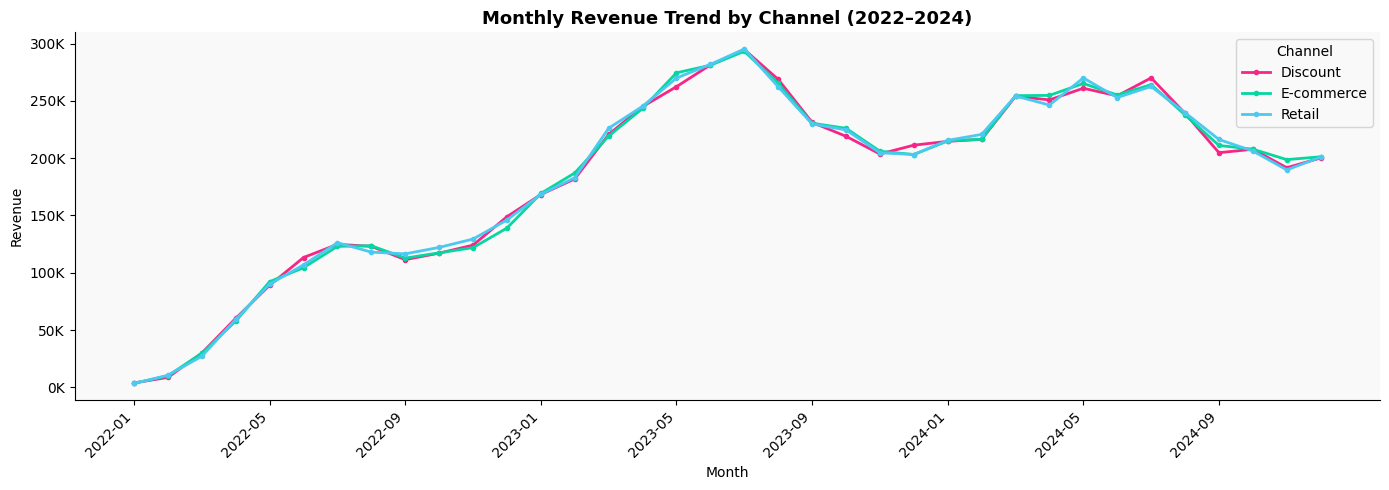

In [14]:
# Monthly channel revenue trend
fig, ax = plt.subplots(figsize=(14, 5))
ch_monthly = df.groupby(["yearmonth","channel"])["revenue"].sum().reset_index()
for channel, grp in ch_monthly.groupby("channel"):
    ax.plot(grp["yearmonth"], grp["revenue"],
            label=channel, color=CH_PAL.get(channel,"#aaa"), linewidth=2, marker="o", markersize=3)

ax.set_title("Monthly Revenue Trend by Channel (2022–2024)", fontsize=13, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
ax.legend(title="Channel")
ticks = [i for i, x in enumerate(ch_monthly["yearmonth"].unique()) if i % 4 == 0]
ax.set_xticks(ticks)
ax.set_xticklabels([ch_monthly["yearmonth"].unique()[i] for i in ticks], rotation=45, ha="right")
plt.tight_layout()

# Regional Analysis
**Business Question:** Is there a region that consistently underperforms? How does performance vary across regions by category?

In [15]:
reg_agg = (
    df.groupby("region")
    .agg(
        total_revenue    = ("revenue",          "sum"),
        total_units      = ("units_sold",       "sum"),
        avg_sell_through = ("sell_through_rate", "mean"),
        avg_delivery     = ("delivery_days",     "mean"),
    )
    .round(2)
    .sort_values("total_revenue", ascending=False)
)
reg_agg["revenue_share_%"] = (reg_agg["total_revenue"] / reg_agg["total_revenue"].sum() * 100).round(1)
reg_agg

,total_revenue,total_units,avg_sell_through,avg_delivery,revenue_share_%
region,,,,,
PL-South,6630137.11,1260811,11.04,3.01,33.4
PL-North,6629067.93,1263281,11.05,3.00,33.4
PL-Central,6585424.18,1254951,11.01,3.00,33.2


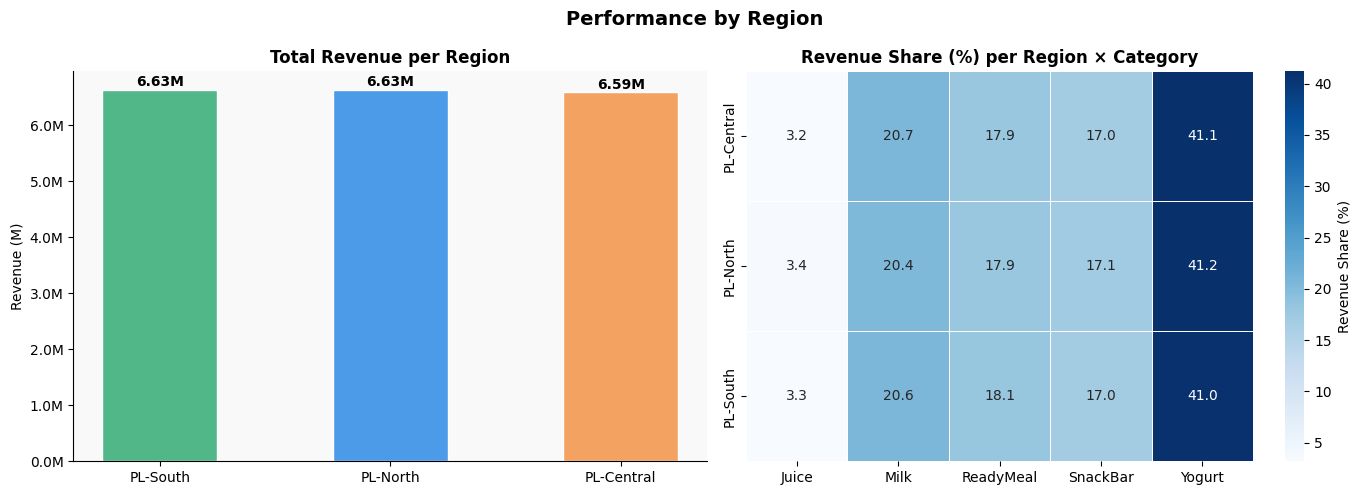

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Performance by Region", fontsize=14, fontweight="bold")
colors = [REG_PAL.get(r,"#aaa") for r in reg_agg.index]

ax = axes[0]
bars = ax.bar(reg_agg.index, reg_agg["total_revenue"], color=colors, width=0.5, edgecolor="white")
ax.set_title("Total Revenue per Region")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_m))
ax.set_ylabel("Revenue (M)")
for bar, val in zip(bars, reg_agg["total_revenue"]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.01,
            f"{val/1e6:.2f}M", ha="center", fontsize=10, fontweight="bold")

ax = axes[1]
pivot_reg_cat = df.pivot_table(values="revenue", index="region", columns="category", aggfunc="sum")
pivot_reg_cat_pct = pivot_reg_cat.div(pivot_reg_cat.sum(axis=1), axis=0) * 100
sns.heatmap(pivot_reg_cat_pct.round(1), annot=True, fmt=".1f", cmap="Blues",
            ax=ax, linewidths=0.5, cbar_kws={"label":"Revenue Share (%)"})
ax.set_title("Revenue Share (%) per Region × Category")
ax.set_xlabel("")
ax.set_ylabel("")

plt.tight_layout()

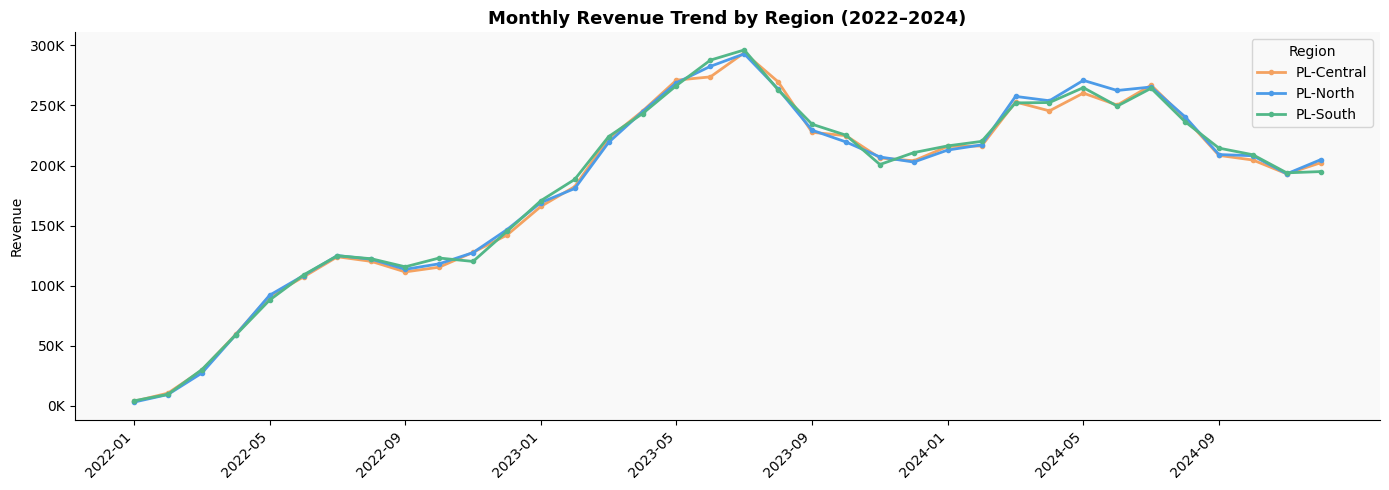

In [17]:
# Region trend YoY
fig, ax = plt.subplots(figsize=(14, 5))
reg_monthly = df.groupby(["yearmonth","region"])["revenue"].sum().reset_index()
for region, grp in reg_monthly.groupby("region"):
    ax.plot(grp["yearmonth"], grp["revenue"],
            label=region, color=REG_PAL.get(region,"#aaa"), linewidth=2, marker="o", markersize=3)
ax.set_title("Monthly Revenue Trend by Region (2022–2024)", fontsize=13, fontweight="bold")
ax.set_ylabel("Revenue")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
ax.legend(title="Region")
ticks = [i for i, x in enumerate(reg_monthly["yearmonth"].unique()) if i % 4 == 0]
ax.set_xticks(ticks)
ax.set_xticklabels([reg_monthly["yearmonth"].unique()[i] for i in ticks], rotation=45, ha="right")
plt.tight_layout()

# Promotion Effect
**Business Question:** How significant is the impact of promotions on units_sold and revenue? Is the effect consistent across all categories?

In [18]:
promo_agg = (
    df.groupby("is_promoted")
    .agg(
        n_transactions   = ("revenue",          "count"),
        avg_units        = ("units_sold",       "mean"),
        avg_revenue      = ("revenue",          "mean"),
        avg_sell_through = ("sell_through_rate", "mean"),
        total_revenue    = ("revenue",          "sum"),
    )
    .round(2)
)
promo_agg["uplift_%"] = ((promo_agg["avg_revenue"] / promo_agg.loc["Non-Promoted","avg_revenue"]) - 1) * 100
promo_agg

,n_transactions,avg_units,avg_revenue,avg_sell_through,total_revenue,uplift_%
is_promoted,,,,,,
Non-Promoted,162296,17.44,91.49,9.70,14848475.43,0.000000
Promoted,28461,33.34,175.54,18.68,4996153.79,91.867964


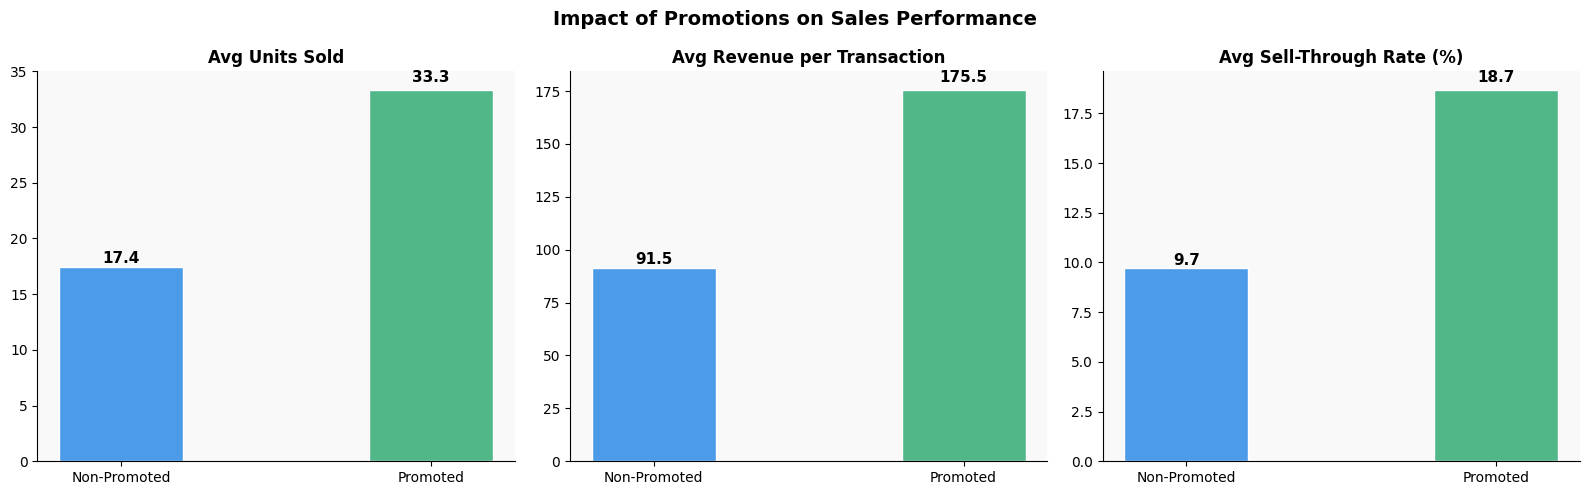

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Impact of Promotions on Sales Performance", fontsize=14, fontweight="bold")
promo_colors = {"Promoted":"#52B788","Non-Promoted":"#4C9BE8"}
colors = [promo_colors.get(p,"#aaa") for p in promo_agg.index]

metrics = [("avg_units","Avg Units Sold"), ("avg_revenue","Avg Revenue per Transaction"), ("avg_sell_through","Avg Sell-Through Rate (%)")]
for ax, (col, title) in zip(axes, metrics):
    bars = ax.bar(promo_agg.index, promo_agg[col], color=colors, width=0.4, edgecolor="white")
    ax.set_title(title)
    for bar, val in zip(bars, promo_agg[col]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.02,
                f"{val:.1f}", ha="center", fontsize=11, fontweight="bold")

plt.tight_layout()

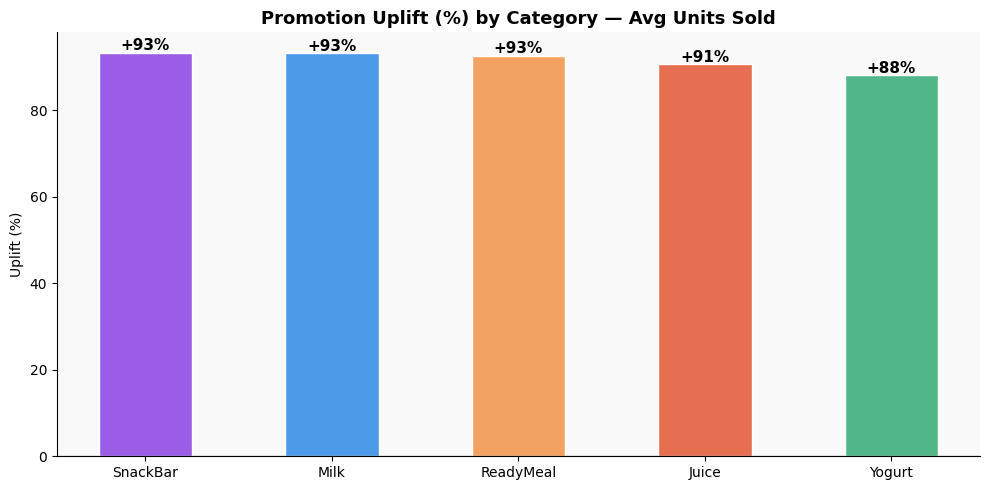

In [20]:
# Promotion effect by category
promo_cat = df.groupby(["category","is_promoted"])["units_sold"].mean().unstack()
promo_cat["uplift_%"] = ((promo_cat["Promoted"] / promo_cat["Non-Promoted"]) - 1) * 100
promo_cat = promo_cat.sort_values("uplift_%", ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors = [CAT_PAL.get(c,"#aaa") for c in promo_cat.index]
bars = ax.bar(promo_cat.index, promo_cat["uplift_%"], color=colors, edgecolor="white", width=0.5)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Promotion Uplift (%) by Category — Avg Units Sold", fontsize=13, fontweight="bold")
ax.set_ylabel("Uplift (%)")
for bar, val in zip(bars, promo_cat["uplift_%"]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f"+{val:.0f}%", ha="center", fontsize=11, fontweight="bold")
plt.tight_layout()

# Time Trend Analysis
**Business Question:** What is the Year-over-Year (YoY) revenue growth? Are there recurring seasonal patterns each year?

In [21]:
# YoY comparison
yoy = df.groupby("year").agg(total_revenue=("revenue","sum"), total_units=("units_sold","sum")).round(0)
yoy["revenue_growth_%"] = yoy["total_revenue"].pct_change() * 100
yoy["units_growth_%"]   = yoy["total_units"].pct_change() * 100
yoy.round(1)

,total_revenue,total_units,revenue_growth_%,units_growth_%
year,,,,
2022,3144046.0,600272,NaN,NaN
2023,8380045.0,1594280,166.5,165.6
2024,8320539.0,1584491,-0.7,-0.6


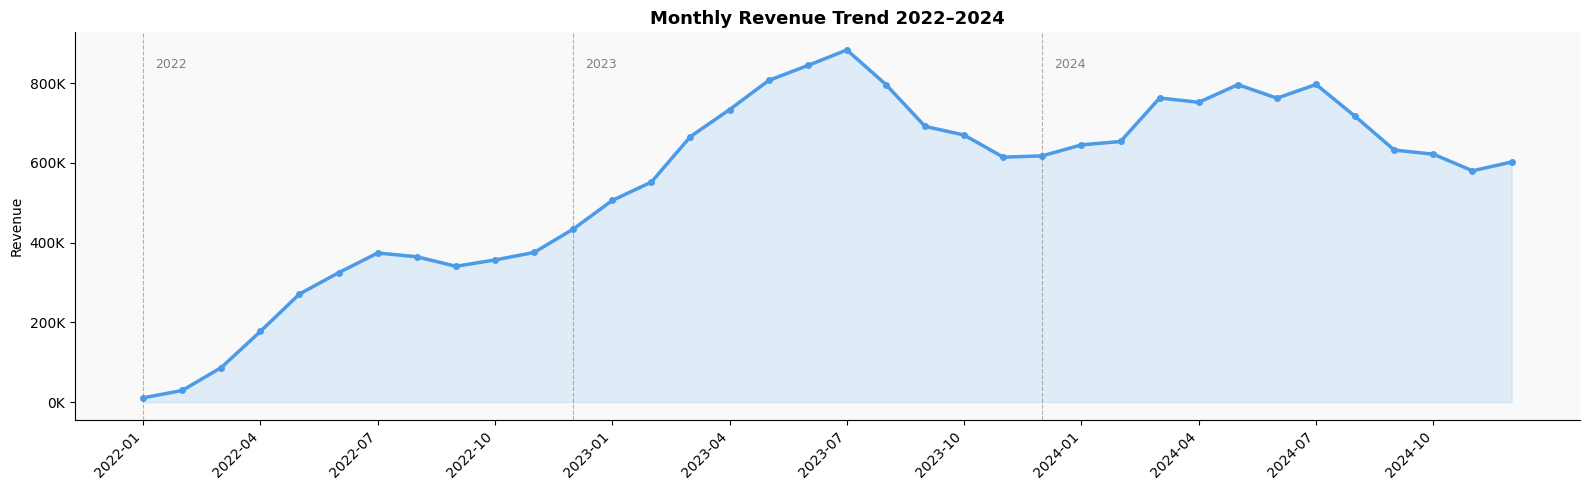

In [22]:
# Monthly trend — overall
monthly_rev = df.groupby("yearmonth")["revenue"].sum().reset_index()

fig, ax = plt.subplots(figsize=(16, 5))
ax.fill_between(range(len(monthly_rev)), monthly_rev["revenue"], alpha=0.15, color="#4C9BE8")
ax.plot(range(len(monthly_rev)), monthly_rev["revenue"], color="#4C9BE8", linewidth=2.5, marker="o", markersize=4)
ax.set_title("Monthly Revenue Trend 2022–2024", fontsize=13, fontweight="bold")
ax.set_ylabel("Revenue")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
ax.set_xticks(range(0, len(monthly_rev), 3))
ax.set_xticklabels(monthly_rev["yearmonth"].iloc[::3], rotation=45, ha="right")
# Annotate year boundaries
for yr, label in [(0,"2022"),(11,"2023"),(23,"2024")]:
    ax.axvline(yr, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
    ax.text(yr+0.3, monthly_rev["revenue"].max()*0.95, label, fontsize=9, color="gray")
plt.tight_layout()

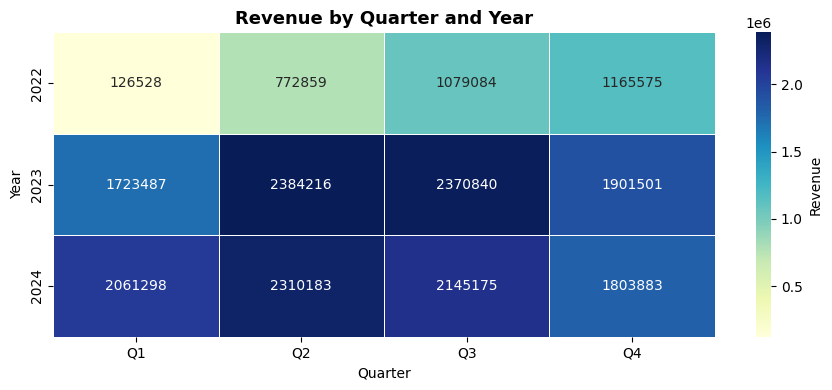

In [23]:
# Quarterly heatmap
quarter_pivot = df.pivot_table(values="revenue", index="year", columns="quarter", aggfunc="sum")
fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(quarter_pivot.round(0), annot=True, fmt=".0f", cmap="YlGnBu",
            ax=ax, linewidths=0.5, cbar_kws={"label":"Revenue"})
ax.set_title("Revenue by Quarter and Year", fontsize=13, fontweight="bold")
ax.set_xlabel("Quarter")
ax.set_ylabel("Year")
plt.tight_layout()

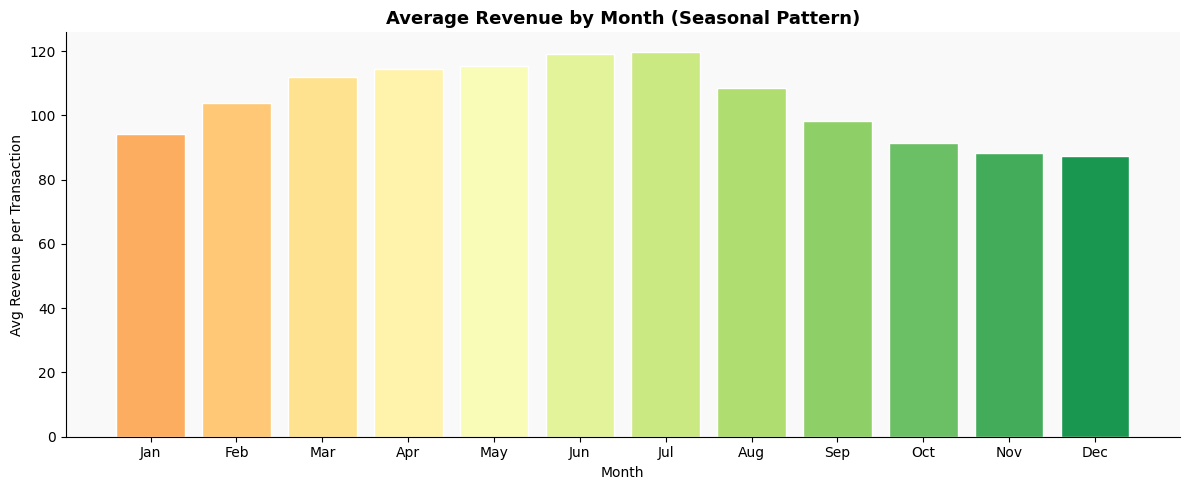

In [24]:
# Seasonality — average revenue per month (across all years)
seasonal = df.groupby(["month","month_name"])["revenue"].mean().reset_index()
seasonal = seasonal.sort_values("month")
MONTH_ORDER = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
seasonal["month_name"] = pd.Categorical(seasonal["month_name"], categories=MONTH_ORDER, ordered=True)
seasonal = seasonal.sort_values("month_name")

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(seasonal["month_name"], seasonal["revenue"],
              color=plt.cm.RdYlGn(np.linspace(0.3, 0.9, 12)), edgecolor="white")
ax.set_title("Average Revenue by Month (Seasonal Pattern)", fontsize=13, fontweight="bold")
ax.set_ylabel("Avg Revenue per Transaction")
ax.set_xlabel("Month")
plt.tight_layout()

# Brand Analysis
 **Business Question:** Which brands are the most dominant? Is brand dominance consistent across all categories?

In [25]:
brand_agg = (
    df.groupby(["category","brand"])
    .agg(total_revenue=("revenue","sum"), total_units=("units_sold","sum"))
    .round(2)
    .reset_index()
    .sort_values("total_revenue", ascending=False)
)

top10_brand = brand_agg.groupby("brand")["total_revenue"].sum().sort_values(ascending=False).head(10)
print("── Top 10 Brand by Total Revenue ──────────────────────")
top10_brand.to_frame().assign(revenue_M=lambda x: (x["total_revenue"]/1e6).round(2))

── Top 10 Brand by Total Revenue ──────────────────────


,total_revenue,revenue_M
brand,,
SnBrand2,2845459.90,2.85
YoBrand4,2455577.77,2.46
YoBrand3,2096588.08,2.10
YoBrand2,1998406.75,2.00
MiBrand3,1661418.09,1.66
YoBrand1,1606805.43,1.61
ReBrand4,1526738.35,1.53
ReBrand2,1249163.30,1.25
MiBrand1,1132295.91,1.13


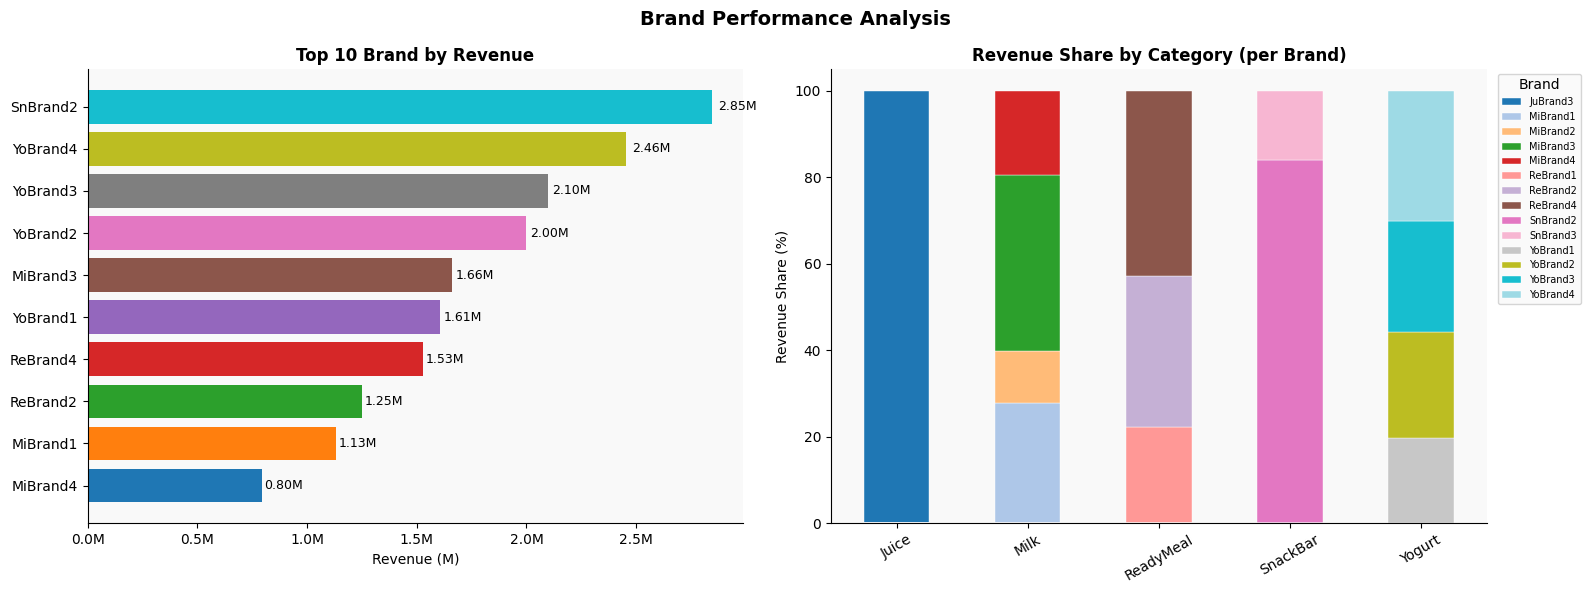

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Brand Performance Analysis", fontsize=14, fontweight="bold")

# Top 10 brand overall
ax = axes[0]
top10 = brand_agg.groupby("brand")["total_revenue"].sum().sort_values().tail(10)
colors_b = plt.cm.tab10(np.linspace(0, 1, 10))
bars = ax.barh(top10.index, top10.values, color=colors_b)
ax.set_title("Top 10 Brand by Revenue")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_m))
ax.set_xlabel("Revenue (M)")
for bar, val in zip(bars, top10.values):
    ax.text(bar.get_width()*1.01, bar.get_y()+bar.get_height()/2,
            f"{val/1e6:.2f}M", va="center", fontsize=9)

# Brand revenue share per category (stacked)
ax = axes[1]
pivot_b_cat = df.pivot_table(values="revenue", index="category", columns="brand", aggfunc="sum").fillna(0)
pivot_b_cat_pct = pivot_b_cat.div(pivot_b_cat.sum(axis=1), axis=0) * 100
pivot_b_cat_pct.plot(kind="bar", stacked=True, ax=ax, colormap="tab20", edgecolor="white", linewidth=0.3)
ax.set_title("Revenue Share by Category (per Brand)")
ax.set_ylabel("Revenue Share (%)")
ax.set_xlabel("")
ax.legend(title="Brand", bbox_to_anchor=(1.01,1), loc="upper left", fontsize=7)
ax.tick_params(axis="x", rotation=30)

plt.tight_layout()

# Sell-Through & Operational Efficiency Analysis
**Business Question:** How efficient is the product distribution? Does delivery speed affect the sell-through rate?

In [27]:
print("Sell-Through Rate by Category")
st_cat = df.groupby("category")["sell_through_rate"].describe().round(2)
print(st_cat)

print("Sell-Through Rate by Channel")
st_ch = df.groupby("channel")["sell_through_rate"].describe().round(2)
print(st_ch)

Sell-Through Rate by Category
             count   mean   std  min   25%    50%    75%    max
category                                                       
Juice       6943.0   9.93  5.23  0.0  6.53   8.89  12.24  42.38
Milk       44595.0   9.77  4.94  0.0  6.63   8.78  11.73  48.74
ReadyMeal  34236.0  11.01  5.30  0.0  7.61  10.00  13.15  48.33
SnackBar   32276.0  11.12  5.60  0.0  7.50  10.00  13.48  44.66
Yogurt     72707.0  11.90  6.21  0.0  7.74  10.67  14.68  62.14
Sell-Through Rate by Channel
              count   mean   std  min   25%   50%    75%    max
channel                                                        
Discount    63450.0  11.04  5.71  0.0  7.32  9.88  13.43  62.14
E-commerce  63619.0  11.06  5.72  0.0  7.33  9.88  13.45  57.14
Retail      63688.0  11.01  5.65  0.0  7.30  9.90  13.39  50.72


/tmp/ipykernel_5201/2060584279.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="sell_through_rate", y="category", order=order_cat,
/tmp/ipykernel_5201/2060584279.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dt_st = df.groupby("delivery_tier")["sell_through_rate"].mean().reset_index()


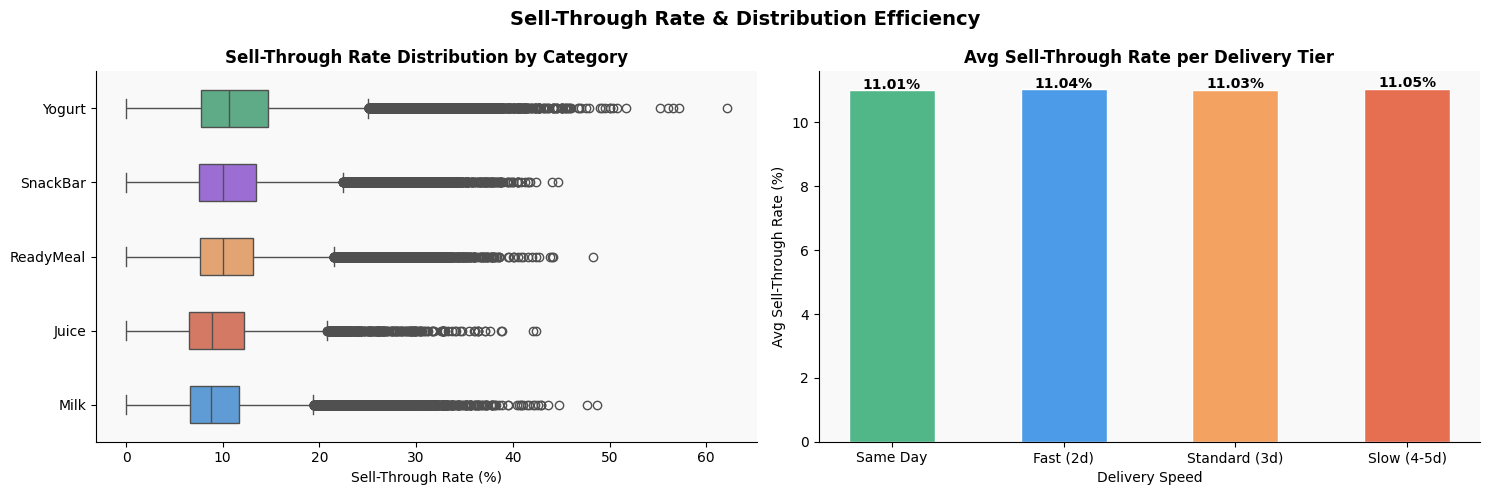

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Sell-Through Rate & Distribution Efficiency", fontsize=14, fontweight="bold")

# Box plot: sell-through rate by category
ax = axes[0]
order_cat = df.groupby("category")["sell_through_rate"].median().sort_values(ascending=False).index
sns.boxplot(data=df, x="sell_through_rate", y="category", order=order_cat,
            palette=CAT_PAL, ax=ax, width=0.5)
ax.set_title("Sell-Through Rate Distribution by Category")
ax.set_xlabel("Sell-Through Rate (%)")
ax.set_ylabel("")

# Delivery tier vs sell-through
ax = axes[1]
dt_st = df.groupby("delivery_tier")["sell_through_rate"].mean().reset_index()
colors_d = ["#52B788","#4C9BE8","#F4A261","#E76F51"]
bars = ax.bar(dt_st["delivery_tier"].astype(str), dt_st["sell_through_rate"],
              color=colors_d, edgecolor="white", width=0.5)
ax.set_title("Avg Sell-Through Rate per Delivery Tier")
ax.set_ylabel("Avg Sell-Through Rate (%)")
ax.set_xlabel("Delivery Speed")
for bar, val in zip(bars, dt_st["sell_through_rate"]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
            f"{val:.2f}%", ha="center", fontsize=10, fontweight="bold")

plt.tight_layout()

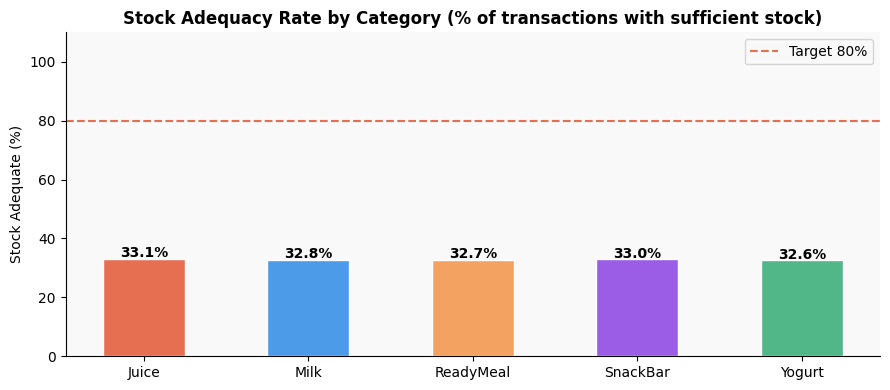

In [29]:
# Stock adequacy per category
stock_adeq = df.groupby("category")["stock_adequate"].mean() * 100
fig, ax = plt.subplots(figsize=(9, 4))
colors_s = [CAT_PAL.get(c,"#aaa") for c in stock_adeq.index]
bars = ax.bar(stock_adeq.index, stock_adeq.values, color=colors_s, edgecolor="white", width=0.5)
ax.axhline(80, color="#E76F51", linestyle="--", linewidth=1.5, label="Target 80%")
ax.set_title("Stock Adequacy Rate by Category (% of transactions with sufficient stock)", fontsize=12, fontweight="bold")
ax.set_ylabel("Stock Adequate (%)")
ax.set_ylim(0, 110)
ax.legend()
for bar, val in zip(bars, stock_adeq.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f"{val:.1f}%", ha="center", fontsize=10, fontweight="bold")
plt.tight_layout()

# Variable Correlation Analysis
**Business Question:** Which variables have the most influence on revenue and units_sold?

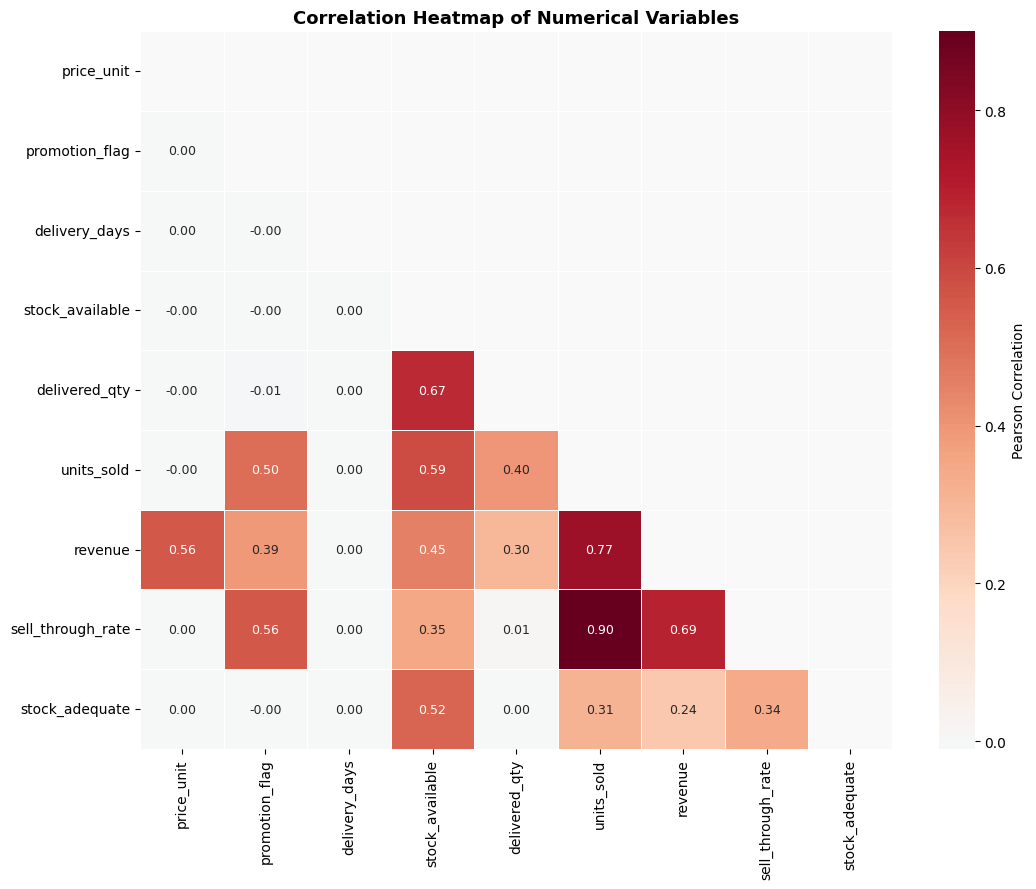

In [30]:
corr_cols = ["price_unit","promotion_flag","delivery_days","stock_available",
             "delivered_qty","units_sold","revenue","sell_through_rate","stock_adequate"]
corr_matrix = df[corr_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))   # upper triangle mask
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, ax=ax, linewidths=0.5,
            cbar_kws={"label":"Pearson Correlation"},
            annot_kws={"size":9})
ax.set_title("Correlation Heatmap of Numerical Variables", fontsize=13, fontweight="bold")
plt.tight_layout()

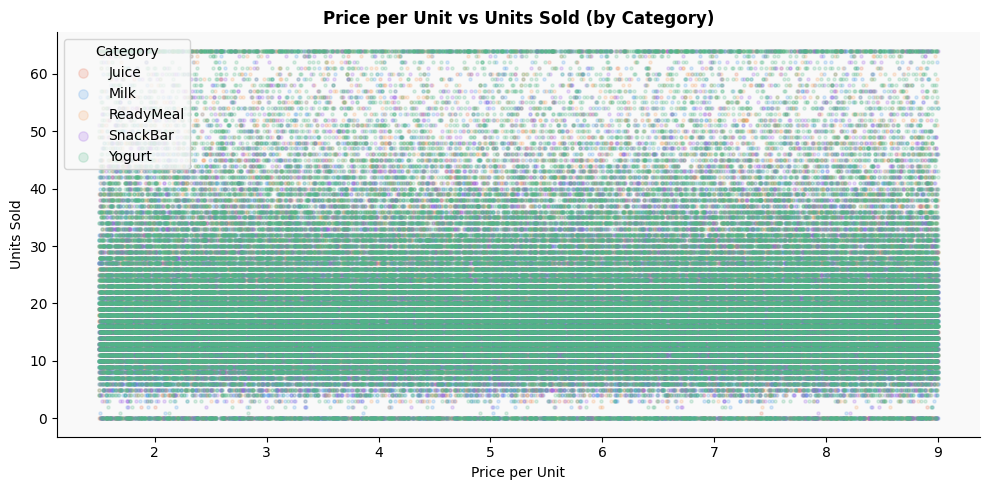

In [31]:
# Scatter price vs units sold (by category)
fig, ax = plt.subplots(figsize=(10, 5))
for cat, grp in df.groupby("category"):
    ax.scatter(grp["price_unit"], grp["units_sold"],
               alpha=0.2, s=5, label=cat, color=CAT_PAL.get(cat,"#aaa"))
ax.set_title("Price per Unit vs Units Sold (by Category)", fontsize=12, fontweight="bold")
ax.set_xlabel("Price per Unit")
ax.set_ylabel("Units Sold")
ax.legend(title="Category", markerscale=3)
plt.tight_layout()